# Interactive display of the divergent pointing

In [2]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import sys
from divtel.telescope import Telescope, Array
from divtel import pointing
from ipywidgets import interact, FloatSlider, IntSlider


In [3]:
def hess_1():
    tel1 = Telescope(100*u.m, 0*u.m, 0*u.m, 20*u.m, 1*u.m)
    tel2 = Telescope(0 * u.m, 100 * u.m, 0 * u.m, 20 * u.m, 1 * u.m)
    tel3 = Telescope(-100 * u.m, 0 * u.m, 0 * u.m, 20 * u.m, 1 * u.m)
    tel4 = Telescope(0 * u.m, -100 * u.m, 0 * u.m, 20 * u.m, 1 * u.m)
    return Array([tel1, tel2, tel3, tel4])

def random_array(n=10):
    tels = [Telescope(1000*np.random.rand()*u.m,
                      1000*np.random.rand() * u.m,
                      0 * u.m,
                      np.random.rand() * u.m,
                      np.random.rand() * u.m,
                      )
            for i in range(n)
            ]
    array = Array(tels)
    for tel in array.telescopes:
        tel.x -= array.barycenter[0]*u.m
        tel.y -= array.barycenter[0]*u.m
        tel.z -= array.barycenter[0]*u.m
    return Array(tels)

In [4]:
array = hess_1()

for tel in array.telescopes:
    tel.point_to_altaz(90*u.deg, 0*u.deg)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


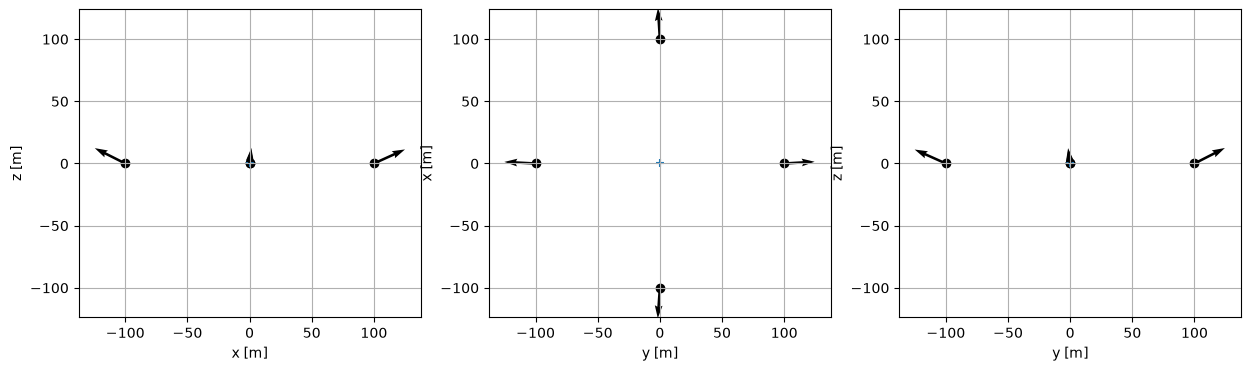

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
array.divergent_pointing(0.9, 80*u.deg, 50*u.deg)
ax = array.display_2d(projection='xz', ax=axes[0])
array.display_2d(projection='xy', ax=axes[1])
array.display_2d(projection='yz', ax=axes[2])
plt.show()

In [9]:
# %matplotlib inlinex
@interact
def interactive_2d(div=(0, 1, 0.01), alt=(0,80), az=(0,90)):
    array.divergent_pointing(div, alt*u.deg, az*u.deg)
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    ax = array.display_2d(projection='xz', ax=axes[0])
    array.display_2d(projection='xy', ax=axes[1])
    array.display_2d(projection='yz', ax=axes[2])
    plt.show()


interactive(children=(FloatSlider(value=0.0, description='div', max=1.0, step=0.01), IntSlider(value=40, descr…

In [7]:
%matplotlib inline
@interact(div=FloatSlider(min=0, max=1, step=0.01, continuous_update=False),
          alt=IntSlider(min=0, max=90, continuous_update=False),
          az=IntSlider(min=0, max=90, continuous_update=False))
def interactive_3d(div, alt, az):
    array.divergent_pointing(div, alt*u.deg, az*u.deg)
    ax = array.display_3d()
    ax.scatter(array.barycenter[0], array.barycenter[1], array.barycenter[2])
    plt.show()


interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='div', max=1.0, step=0.01), …